# Calculate the seeing

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits 
from spectral_cube import SpectralCube
from astropy.visualization import make_lupton_rgb, ManualInterval, make_rgb, LogStretch
from astropy.modeling import models, fitting
import astropy.units as u
from astropy.wcs.utils import pixel_to_skycoord, proj_plane_pixel_scales

In [2]:
file = fits.open('Mrk996.fits')
cube = SpectralCube.read(file[1])
file.close()

In [8]:
import numpy as np
import astropy.units as u

from astropy.modeling import models, fitting
from astropy.wcs.utils import proj_plane_pixel_scales


def measure_fwhm(
    cube,
    center_pos=(177, 197),
    radius=0.6,
    n_points=100
):
    """
    Measure the spatial FWHM of a source using a 2D Moffat fit.

    Parameters
    ----------
    cube : SpectralCube
        Input spectral cube.

    center_pos : tuple
        Source position in pixel coordinates as (y, x).

    radius : float
        Radius of the circular fitting region in arcsec.

    n_points : int
        Number of evenly spaced spectral channels to measure.

    Returns
    -------
    wavelengths : Quantity
        Spectral coordinates of the selected channels.

    fwhm_values : Quantity
        Moffat FWHM values in arcsec. NaN is returned for
        channels with no valid data or failed fits.
    """

    # ---------------------------------------------------------
    # Pixel scale
    # ---------------------------------------------------------
    pixel_scales = (
        proj_plane_pixel_scales(cube.wcs.celestial) * u.deg
    )

    scale_y = pixel_scales[0].to(u.arcsec)
    scale_x = pixel_scales[1].to(u.arcsec)

    print(f"Pixel scale X: {scale_x}")
    print(f"Pixel scale Y: {scale_y}")

    # ---------------------------------------------------------
    # Source position
    # ---------------------------------------------------------
    y0, x0 = center_pos

    # Check that the position is inside the image
    ny, nx = cube.shape[1:]

    if not (0 <= y0 < ny and 0 <= x0 < nx):
        raise ValueError(
            f"center_pos={center_pos} is outside the image. "
            f"Image size is ({ny}, {nx}) pixels."
        )

    # ---------------------------------------------------------
    # Select evenly spaced channels
    # ---------------------------------------------------------
    n_channels = cube.shape[0]

    channels = np.linspace(
        0,
        n_channels - 1,
        n_points,
        dtype=int
    )

    # Remove duplicate channels
    channels = np.unique(channels)

    wavelengths = cube.spectral_axis[channels]

    # ---------------------------------------------------------
    # Create pixel coordinate grid
    # ---------------------------------------------------------
    yy, xx = np.indices((ny, nx))

    # ---------------------------------------------------------
    # Distance from source in arcsec
    # ---------------------------------------------------------
    distance = np.sqrt(
        ((xx - x0) * scale_x.value)**2 +
        ((yy - y0) * scale_y.value)**2
    )

    # Circular fitting region
    circular_mask = distance <= radius

    # ---------------------------------------------------------
    # Moffat fitter
    # ---------------------------------------------------------
    fitter = fitting.LevMarLSQFitter()

    fwhm_values = []

    # ---------------------------------------------------------
    # Loop through selected channels
    # ---------------------------------------------------------
    for channel in channels:

        print(f"Fitting channel {channel}...")

        # Extract 2D image
        image = cube[channel].value

        # -----------------------------------------------------
        # Check for completely zero/invalid image
        # -----------------------------------------------------
        valid = (
            np.isfinite(image) &
            (image != 0)
        )

        if not np.any(valid):
            print("  → Empty image, returning NaN")
            fwhm_values.append(np.nan)
            continue

        # -----------------------------------------------------
        # Apply circular mask
        # -----------------------------------------------------
        mask = circular_mask & valid

        # No valid pixels inside fitting region
        if not np.any(mask):
            print("  → No valid pixels inside mask, returning NaN")
            fwhm_values.append(np.nan)
            continue

        # Pixels used for fitting
        x_fit = xx[mask]
        y_fit = yy[mask]
        z_fit = image[mask]

        # -----------------------------------------------------
        # Initial Moffat model
        # -----------------------------------------------------
        amplitude = np.nanmax(z_fit)

        model_init = models.Moffat2D(
            amplitude=amplitude,
            x_0=x0,
            y_0=y0,
            gamma=3.0,
            alpha=2.0
        )

        # -----------------------------------------------------
        # Fit Moffat
        # -----------------------------------------------------
        try:

            fitted_model = fitter(
                model_init,
                x_fit,
                y_fit,
                z_fit
            )

            # -------------------------------------------------
            # Extract Moffat parameters
            # -------------------------------------------------
            gamma = fitted_model.gamma.value
            alpha = fitted_model.alpha.value

            # -------------------------------------------------
            # Moffat FWHM in pixels
            # -------------------------------------------------
            fwhm_pix = (
                2
                * gamma
                * np.sqrt(
                    2**(1 / alpha) - 1
                )
            )

            # -------------------------------------------------
            # Convert pixels → arcsec
            # -------------------------------------------------
            pixel_scale = np.sqrt(
                scale_x.value * scale_y.value
            )

            fwhm = fwhm_pix * pixel_scale

            fwhm_values.append(fwhm)

            print(f"  → FWHM = {fwhm:.4f} arcsec")

        except Exception as e:

            print(f"  → Fit failed: {e}")
            fwhm_values.append(np.nan)

    # ---------------------------------------------------------
    # Return results
    # ---------------------------------------------------------
    return wavelengths, np.array(fwhm_values) * u.arcsec

In [15]:
wavelengths, fwhm = measure_fwhm(
    cube,
    center_pos=(177, 197),
    radius=0.2,
    n_points=500
)

Pixel scale X: 0.025419999999999995 arcsec
Pixel scale Y: 0.025189999999999994 arcsec
Fitting channel 0...


/tmp/ipykernel_52917/3927576663.py:184: RuntimeWarning: invalid value encountered in sqrt
  * np.sqrt(


  → FWHM = nan arcsec
Fitting channel 7...
  → FWHM = 0.3473 arcsec
Fitting channel 14...
  → FWHM = 0.2661 arcsec
Fitting channel 22...


  → FWHM = 0.4254 arcsec
Fitting channel 29...
  → FWHM = 0.1392 arcsec
Fitting channel 36...
  → FWHM = 0.2949 arcsec
Fitting channel 44...
  → FWHM = 0.3361 arcsec
Fitting channel 51...


  → FWHM = 0.3186 arcsec
Fitting channel 58...
  → FWHM = 0.2443 arcsec
Fitting channel 66...
  → FWHM = 0.3777 arcsec
Fitting channel 73...
  → FWHM = 0.3061 arcsec
Fitting channel 81...


...

  → FWHM = 0.1814 arcsec
Fitting channel 3554...
  → FWHM = 0.1747 arcsec
Fitting channel 3562...
  → FWHM = -0.1590 arcsec
Fitting channel 3569...
  → FWHM = 0.1792 arcsec
Fitting channel 3576...


  → FWHM = 0.3223 arcsec
Fitting channel 3584...
  → FWHM = 0.1763 arcsec
Fitting channel 3591...
  → FWHM = 0.2197 arcsec
Fitting channel 3598...
  → FWHM = 0.1842 arcsec
Fitting channel 3606...


  → FWHM = 0.2003 arcsec
Fitting channel 3613...
  → FWHM = 0.1724 arcsec
Fitting channel 3621...
  → FWHM = 0.2851 arcsec
Fitting channel 3628...
  → FWHM = 0.2609 arcsec
Fitting channel 3635...


  → FWHM = 0.1943 arcsec
Fitting channel 3643...
  → FWHM = 0.2032 arcsec
Fitting channel 3650...
  → FWHM = 0.2284 arcsec
Fitting channel 3657...


  → FWHM = 0.1586 arcsec
Fitting channel 3665...
  → FWHM = 0.1929 arcsec
Fitting channel 3672...
  → FWHM = 0.1829 arcsec
Fitting channel 3680...
  → FWHM = 0.0152 arcsec


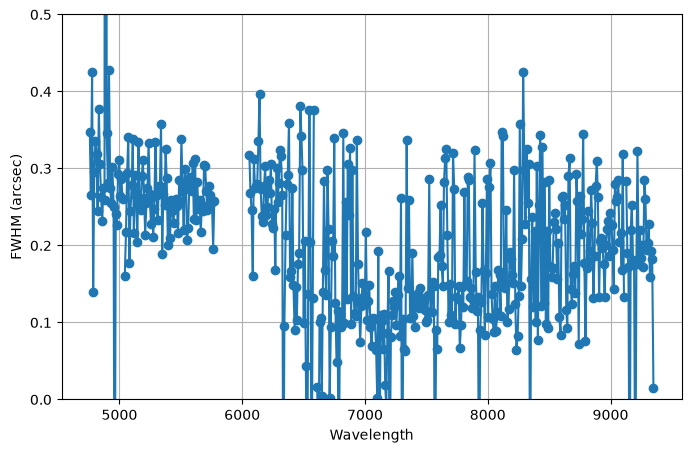

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    wavelengths,
    fwhm,
    marker="o",
    linestyle="-"
)

plt.xlabel("Wavelength")
plt.ylabel("FWHM (arcsec)")

plt.ylim(0, 0.5)

plt.grid(True)

plt.show()